# American Option Pricing - PINN vs Binomial Tree (CRR) vs Black-Scholes European

We price an **American put** option under three methods:

| Method | Type | Framework |
|---|---|---|
| **PINN-BS** | American (LCP penalty) | Black-Scholes PDE + early-exercise constraint |
| **Binomial Tree (CRR)** | American (exact DP) | Cox-Ross-Rubinstein lattice, N=1000 steps |
| **BS European** | European lower bound | Closed-form Black-Scholes put |

The American put satisfies the **Linear Complementarity Problem (LCP)**:
$$\min\left(-\mathcal{L}_{BS}V,\; V - (K-S)^+\right) = 0$$

The PINN enforces the early-exercise constraint via a **hinge penalty**:
$$\mathcal{L}_{\text{exercise}} = \left\|\text{ReLU}\left((K-S)^+ - V\right)\right\|^2$$

This term is zero in the continuation region ($V > K-S$) and penalises violations in the exercise region. The **free boundary**, the critical stock price below which early exercise is optimal, is clearly visible in the plots.


## Library

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import ndtr

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm.auto import tqdm
import time

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

torch.set_default_dtype(torch.float32)
print("Device:", device)

Device: cuda


## Black-Scholes - European Put (closed-form lower bound)

In [2]:
class BlackScholes:
    """Vectorised Black-Scholes pricer for European options."""
    TAU_EPS = 1e-8 
    S_EPS   = 1e-12  

    def __init__(self, r, sigma):
        self.r     = r
        self.sigma = sigma

    def price(self, S, K, tau, option_type="put"):
        S   = np.asarray(S,   dtype=float)
        tau = np.asarray(tau, dtype=float)

        payoff      = np.maximum(K - S, 0.0) if option_type == "put" else np.maximum(S - K, 0.0)
        near_expiry = tau <= self.TAU_EPS

        if np.all(near_expiry):
            return payoff

        S_safe   = np.maximum(S,   self.S_EPS)
        tau_safe = np.maximum(tau, self.TAU_EPS)
        sqrt_tau = np.sqrt(tau_safe)

        d1   = (np.log(S_safe / K) + (self.r + 0.5 * self.sigma**2) * tau_safe) / (self.sigma * sqrt_tau)
        d2   = d1 - self.sigma * sqrt_tau
        disc = K * np.exp(-self.r * tau_safe)

        if option_type == "put":
            value = disc * ndtr(-d2) - S_safe * ndtr(-d1)
        else:
            value = S_safe * ndtr(d1) - disc * ndtr(d2)

        return np.where(near_expiry, payoff, value)

    def price_grid(self, S_arr, K, tau, option_type="put"):
        return self.price(S_arr, K, tau, option_type)

## Binomial Tree - CRR (American put benchmark)

Cox-Ross-Rubinstein lattice with N steps.
Early exercise enforced at each node: $V_i = \max(V_i^{\text{cont}},\, K - S_i)$.


In [3]:
class BinomialTree:
    """CRR binomial tree pricer for American options."""

    def __init__(self, r, sigma, N=1000):
        self.r     = r
        self.sigma = sigma
        self.N     = N

    def price(self, S0, K, T, option_type="put"):
        return float(self.price_grid([S0], K, T, option_type)[0])

    def price_grid(self, S_arr, K, T, option_type="put"):
        S_arr = np.asarray(S_arr, dtype=float)

        if T <= 1e-10:
            return np.maximum(K - S_arr, 0.0) if option_type == "put" else np.maximum(S_arr - K, 0.0)

        N, r, sigma = self.N, self.r, self.sigma

        dt   = T / N
        u    = math.exp(sigma * math.sqrt(dt))
        d    = 1.0 / u
        disc = math.exp(-r * dt)
        p    = (math.exp(r * dt) - d) / (u - d)
        q    = 1.0 - p

        j = np.arange(N + 1)
        S = S_arr[:, None] * (u ** (N - j)) * (d ** j)
        V = np.maximum(K - S, 0.0) if option_type == "put" else np.maximum(S - K, 0.0)

        scale = 1.0 / u

        for i in range(N - 1, -1, -1):
            V        = disc * (p * V[:, :-1] + q * V[:, 1:])
            exercise = np.maximum(K - S[:, :i+1] * scale, 0.0) if option_type == "put" \
                       else np.maximum(S[:, :i+1] * scale - K, 0.0)
            V        = np.maximum(V, exercise)
            scale   /= u

        return V[:, 0]


## PINN - American Put (LCP Penalty Method)

### Problem formulation

An American put gives the holder the right to sell one unit of the underlying at
strike $K$ at **any** time $t \in [0, T]$.  The holder's optimal strategy defines
a **free boundary** $S^*(t)$: exercise immediately if $S \leq S^*(t)$, hold otherwise.

The value function $V(S,t)$ satisfies the **Linear Complementarity Problem (LCP)**:

$$\min\!\Big(-\mathcal{L}_{BS}\,V,\;\; V - (K-S)^+\Big) = 0$$

which is shorthand for three simultaneous conditions:

| Condition | Region | Meaning |
|---|---|---|
| $\mathcal{L}_{BS}\,V = 0$ | Continuation $V > (K-S)^+$ | Holds like a European option |
| $\mathcal{L}_{BS}\,V \leq 0$ | Everywhere | No arbitrage |
| $V \geq (K-S)^+$ | Everywhere | Can always exercise |

where the Black-Scholes operator is:

$$\mathcal{L}_{BS}\,V \;=\; \frac{\partial V}{\partial t}
+ \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}
+ rS\frac{\partial V}{\partial S} - rV$$

---

### Boundary and terminal conditions

| Condition | Formula | Reason |
|---|---|---|
| Terminal | $V(S,T) = (K-S)^+$ | Payoff at expiry |
| Lower boundary | $V(0,t) = K$ | $S=0$ is absorbing; immediate exercise always optimal |
| Upper boundary | $V(S_{\max},t) \approx 0$ | Deep OTM put is worthless |
| Obstacle | $V(S,t) \geq (K-S)^+$ | Early exercise is always admissible |

---

### Neural network

The network takes $(S, t)$ as input and outputs a scalar $V > 0$:

$$V_\theta(S,t) = \texttt{softplus}\!\Big(\text{NN}_\theta(\hat S,\, \hat t)\Big)$$

where inputs are normalised to $[-1, 1]$:

$$\hat S = \frac{2(S - S_{\min})}{S_{\max} - S_{\min}} - 1, \qquad
  \hat t = \frac{2(t - t_{\min})}{t_{\max} - t_{\min}} - 1$$

The $\texttt{softplus}$ output activation enforces $V > 0$ globally; the obstacle
penalty then additionally enforces $V \geq (K-S)^+$.

---

### Loss function

The total loss is a weighted sum of five terms:

$$\mathcal{L} = w_{\text{pde}}\,\mathcal{L}_{\text{pde}}
             + w_{\text{ter}}\,\mathcal{L}_{\text{ter}}
             + w_{S=0}\,\mathcal{L}_{S=0}
             + w_{S_{\max}}\,\mathcal{L}_{S_{\max}}
             + w_{\text{ex}}\,\mathcal{L}_{\text{ex}}$$

**PDE loss**: encodes both LCP conditions on the residual $\mathcal{R} = \mathcal{L}_{BS}V / K$:

$$\mathcal{L}_{\text{pde}} = \underbrace{\frac{1}{N}\sum_i \text{ReLU}(\mathcal{R}_i)^2}_{\text{sign: enforce } \mathcal{R} \leq 0}
\;+\; \underbrace{\frac{1}{|\mathcal{C}|}\sum_{i \in \mathcal{C}} \mathcal{R}_i^2}_{\text{cont: enforce } \mathcal{R} = 0 \text{ in continuation}}$$

where $\mathcal{C} = \{i : V_i > (K-S_i)^+ + \varepsilon K\} \cup \{i : S_i \geq K\}$
is the detected continuation region ($\varepsilon = 10^{-3}$).

**Terminal loss**:
$$\mathcal{L}_{\text{ter}} = \frac{1}{N}\sum_i \left(\frac{V(S_i,T) - (K-S_i)^+}{K}\right)^2$$

**Boundary losses**:
$$\mathcal{L}_{S=0} = \frac{1}{N}\sum_i \left(\frac{V(0,t_i) - K}{K}\right)^2, \qquad
  \mathcal{L}_{S_{\max}} = \frac{1}{N}\sum_i \left(\frac{V(S_{\max},t_i)}{K}\right)^2$$

**Obstacle (early-exercise) loss** — one-sided hinge that only penalises violations:
$$\mathcal{L}_{\text{ex}} = \frac{1}{N}\sum_i \text{ReLU}\!\left(\frac{(K-S_i)^+ - V(S_i,t_i)}{K}\right)^2$$

All terms are normalised by $K$ so losses are dimensionless and comparable regardless
of the strike level.

---

### Collocation point sampling

Uniform sampling over $(S,t)$ is inefficient because the solution is smooth and
nearly trivial for deep OTM/deep ITM regions.  Points are concentrated where the
solution is hardest to learn:

| Region | Fraction | Purpose |
|---|---|---|
| ATM band $S \in [K(1-b),\, K(1+b)]$ | `atm_fraction` | Free boundary, highest curvature |
| ITM $S \in (0, K)$ | `itm_fraction` | Exercise region |
| Global $S \in (0, S_{\max})$ | remainder | Coverage across full domain |

---

### Training schedule

| Phase | Optimiser | Notes |
|---|---|---|
| Phase 1 | Adam | PDE weight warmed up from 1 → 10 over first 4 000 epochs |
| Phase 2 | L-BFGS (strong Wolfe) | Fine-tunes on a fixed collocation set; recovers sharp gradients near free boundary |


In [4]:
class PINN_American_Put(nn.Module):
    """
    PINN for American put pricing via the Black-Scholes LCP.

    Enforces:
      - PDE residual <= 0 everywhere            (sign penalty)
      - PDE residual  = 0 in continuation region
      - V(S, T)  = (K - S)+                      (terminal)
      - V(0, t)  = K                             (lower boundary: immediate exercise)
      - V(Smax, t) ≈ 0                           (upper boundary)
      - V >= (K - S)+                            (obstacle / early-exercise)
    """
    _CONT_TOL = 1e-3   # continuation-region threshold, relative to K

    def __init__(self,
                 K, r, sigma, T,
                 S_min, S_max, t_min, t_max,
                 hidden_layers,
                 activation_fun=nn.Tanh,
                 loss_weights=None,
                 atm_fraction=0.4,
                 itm_fraction=0.3,
                 atm_bandwidth=0.30):
        super().__init__()

        self.K, self.r, self.sigma, self.T = K, r, sigma, T
        self.S_min, self.S_max = S_min, S_max
        self.t_min, self.t_max = t_min, t_max
        self.atm_fraction = atm_fraction
        self.itm_fraction = itm_fraction
        self.S_atm_lo = K * (1.0 - atm_bandwidth)
        self.S_atm_hi = K * (1.0 + atm_bandwidth)

        self._S_range = S_max - S_min
        self._t_range = t_max - t_min

        if loss_weights is None:
            loss_weights = {
                            "pde":           1.0,
                            "terminal":      1.0,
                            "boundary_S0":   1.0,
                            "boundary_Smax": 1.0,
                            "exercise":      1.0,
                            }
        self.loss_weights = loss_weights

        # network
        layers, in_dim = [], 2
        for h in hidden_layers:
            layers += [nn.Linear(in_dim, h), activation_fun()]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

        # xavier 
        act_name = activation_fun.__name__.lower()
        gain = nn.init.calculate_gain(act_name if act_name in ("tanh", "relu", "sigmoid") else "tanh")
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=gain)
                nn.init.zeros_(m.bias)

    def forward(self, S, t):
        S_scaled = 2.0 * (S - self.S_min) / self._S_range - 1.0
        t_scaled = 2.0 * (t - self.t_min) / self._t_range - 1.0
        return F.softplus(self.net(torch.cat([S_scaled, t_scaled], dim=1)))

    def _grad(self, y, x):
        """Gradient of y w.r.t. x, keeping the graph for higher-order derivatives."""
        return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]

    def _pde_residual(self, S, t):
        """
        BS operator applied to V:
          residual = V_t + 0.5*sigma^2*S^2*V_SS + r*S*V_S - r*V
        Returns (residual, V, S) where S has requires_grad=True.
        """
        S    = S.detach().requires_grad_(True)
        t    = t.detach().requires_grad_(True)
        V    = self.forward(S, t)
        V_t  = self._grad(V,   t)
        V_S  = self._grad(V,   S)
        V_SS = self._grad(V_S, S)
        res  = V_t + 0.5 * self.sigma**2 * S**2 * V_SS + self.r * S * V_S - self.r * V
        return res, V, S

    def _sample_S(self, N, dev):
        """Concentrated sampling: ATM band, ITM region, plus global spread."""
        eps   = 1e-6
        N_atm = int(N * self.atm_fraction)
        N_itm = int(N * self.itm_fraction)
        N_gl  = N - N_atm - N_itm
        S_atm = torch.rand(N_atm, 1, device=dev) * (self.S_atm_hi - self.S_atm_lo) + self.S_atm_lo
        S_itm = torch.rand(N_itm, 1, device=dev) * (self.K - eps) + eps
        S_gl  = torch.rand(N_gl,  1, device=dev) * (self.S_max - eps) + eps
        return torch.cat([S_atm, S_itm, S_gl])

    def _sample_t(self, N, dev):
        """Uniform samples in [t_min, t_max]."""
        return torch.rand(N, 1, device=dev) * self._t_range + self.t_min

    def sample_training_points(self, N_f, N_terminal, N_b):
        dev = next(self.parameters()).device

        S_f,  t_f  = self._sample_S(N_f, dev), self._sample_t(N_f, dev)
        S_ex, t_ex = self._sample_S(N_f, dev), self._sample_t(N_f, dev)

        N_kink  = N_terminal // 5
        N_bulk  = N_terminal - N_kink

        S_T_bulk  = self._sample_S(N_bulk, dev)
        S_T_kink  = torch.randn(N_kink, 1, device=dev) * (0.03 * self.K) + self.K
        S_T_kink  = S_T_kink.clamp(self.S_min + 1e-6, self.S_max)

        S_T = torch.cat([S_T_bulk, S_T_kink])
        t_T = torch.full((N_terminal, 1), self.T, device=dev)

        S_b0 = torch.full((N_b, 1), self.S_min, device=dev)
        S_b1 = torch.full((N_b, 1), self.S_max, device=dev)
        t_b0 = self._sample_t(N_b, dev)
        t_b1 = self._sample_t(N_b, dev)

        return S_f, t_f, S_T, t_T, S_b0, t_b0, S_b1, t_b1, S_ex, t_ex

    def payoff(self, S):
        return torch.clamp(self.K - S, min=0.0)

    def compute_loss_from_data(self, data, pde_weight_override=None):
        S_f, t_f, S_T, t_T, S_b0, t_b0, S_b1, t_b1, S_ex, t_ex = data
        w = self.loss_weights

        # PDE: LCP conditions
        res, V_f, S_pde = self._pde_residual(S_f, t_f)
        payoff_f        = self.payoff(S_pde)
        res_scaled      = res / self.K

        # residual must be <= 0 everywhere
        loss_pde_sign = torch.mean(F.relu(res_scaled) ** 2)

        # residual must be = 0 in the continuation region
        in_continuation = ((V_f.detach() > payoff_f.detach() + self._CONT_TOL * self.K) | (S_pde.detach() >= self.K)).view(-1)

        loss_pde_cont = (torch.mean(res_scaled.view(-1)[in_continuation] ** 2) if in_continuation.any() else torch.zeros((), device=S_f.device))

        loss_pde = loss_pde_sign + loss_pde_cont

        # terminal: V(S, T) = (K - S)+
        loss_ter = torch.mean(((self.forward(S_T, t_T) - self.payoff(S_T)) / self.K) ** 2)

        # lower boundary: V(0, t) = K 
        loss_b0 = torch.mean(((self.forward(S_b0, t_b0) - self.payoff(S_b0)) / self.K) ** 2)

        # upper boundary: V(S_max, t) = 0 
        loss_b1 = torch.mean((self.forward(S_b1, t_b1) / self.K) ** 2)

        # obstacle: V >= (K - S)+
        loss_ex = torch.mean(F.relu((self.payoff(S_ex) - self.forward(S_ex, t_ex)) / self.K) ** 2)

        # total
        w_pde = pde_weight_override if pde_weight_override is not None else w["pde"]

        loss = (w_pde                * loss_pde
                + w["terminal"]      * loss_ter
                + w["boundary_S0"]   * loss_b0
                + w["boundary_Smax"] * loss_b1
                + w["exercise"]      * loss_ex)

        return loss, {"loss_pde":      loss_pde.item(),
                      "loss_terminal": loss_ter.item(),
                      "loss_b0":       loss_b0.item(),
                      "loss_b1":       loss_b1.item(),
                      "loss_exercise": loss_ex.item(),
                      "loss_pde_sign": loss_pde_sign.item(),
                      "loss_pde_cont": loss_pde_cont.item()}

    def compute_loss(self, N_f, N_terminal, N_b, pde_weight_override=None):
        data = self.sample_training_points(N_f, N_terminal, N_b)
        return self.compute_loss_from_data(data, pde_weight_override=pde_weight_override)

## Initialization

In [5]:
# option parameters 
K     = 100.0
r     = 0.05
sigma = 0.20
T     = 1.0

S_min, S_max = 0.0, 200.0  
t_min, t_max = 0.0, T       

# sampling 
N_f            = 20_000   # interior collocation points
N_terminal     = 5_000    # terminal condition points
N_b            = 8_000    # boundary points (each boundary)
resample_every = 200      # resample collocation points every N epochs

# network 
hidden_layers  = [128, 128, 128, 128]
activation_fun = nn.Tanh

# loss weights
loss_weights = {
                "pde":           1.0,
                "terminal":      30.0,
                "boundary_S0":   20.0,
                "boundary_Smax":  2.0,
                "exercise":       50.0,
                }

# optimiser 
lr     = 5e-4
epochs = 10_000

# iniliazitation of models
bs   = BlackScholes(r, sigma)
tree = BinomialTree(r, sigma, N=1000)

model = PINN_American_Put(K, r, sigma, T, S_min, S_max, t_min, t_max,
                          hidden_layers, activation_fun = activation_fun, loss_weights = loss_weights,
                          atm_fraction = 0.45, itm_fraction = 0.15, atm_bandwidth = 0.35).to(device)

print(f"Parameters     : {sum(p.numel() for p in model.parameters()):,}")
print(f"Architecture   : {hidden_layers} + {activation_fun.__name__}")
print(f"Resample every : {resample_every} epochs")

Parameters     : 50,049
Architecture   : [128, 128, 128, 128] + Tanh
Resample every : 200 epochs


## Training + Optimization

In [6]:
# helpers
def fmt_time(seconds):
    m = int(seconds // 60)
    s = seconds % 60
    return f"{m}m {s:.1f}s"

def save_best_if_needed(current_loss, step, phase):
    if current_loss < best["loss"]:
        best["loss"]  = current_loss
        best["step"]  = step
        best["phase"] = phase
        torch.save({
            "step":              step,
            "phase":             phase,
            "loss":              current_loss,
            "model_state_dict":  model.state_dict(),
        }, best_path)

# tracking 
loss_keys = ["loss_pde", "loss_terminal", "loss_b0",  "loss_b1", "loss_exercise", "loss_pde_sign", "loss_pde_cont"]

loss_history  = []
lbfgs_history = []
parts_history = {k: [] for k in loss_keys}

best_path = "best_pinn_american_put.pt"
best      = {"loss": float("inf"), "step": None, "phase": None}

# scheduler / constants 
PDE_WARMUP_EPOCHS = 4_000          
PDE_W_FINAL       = 10.0

print_every = 500
pbar_every  = 25

optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=800)

# Adam phase 
data       = model.sample_training_points(N_f, N_terminal, N_b)
train_start = time.time()

pbar = tqdm(range(1, epochs + 1), desc="Adam")
for epoch in pbar:

    # resample
    if epoch % resample_every == 0:
        data = model.sample_training_points(N_f, N_terminal, N_b)

    pde_w = 1.0 + (PDE_W_FINAL - 1.0) * min(epoch / PDE_WARMUP_EPOCHS, 1.0)

    optimizer.zero_grad(set_to_none=True)
    loss, parts = model.compute_loss_from_data(data, pde_weight_override=pde_w)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    current_loss = loss.item()
    scheduler.step(current_loss)

    loss_history.append(current_loss)
    for k in loss_keys:
        parts_history[k].append(parts[k])

    save_best_if_needed(current_loss, epoch, "Adam")

    elapsed = time.time() - train_start
    if epoch % pbar_every == 0 or epoch == 1:
        pbar.set_postfix(loss=f"{current_loss:.3e}", pde_w=f"{pde_w:.1f}", time=fmt_time(elapsed))
    if epoch % print_every == 0 or epoch == 1:
        print(
            f"Epoch {epoch:5d} | Total {current_loss:.4e} | "
            f"PDE(w={pde_w:.1f}) {parts['loss_pde']:.3e} | "
            f"Terminal {parts['loss_terminal']:.3e} | "
            f"Exercise {parts['loss_exercise']:.3e} | "
            f"S=0 {parts['loss_b0']:.3e} | S=max {parts['loss_b1']:.3e} | "
            f"Time {fmt_time(elapsed)}"
            )

adam_time = time.time() - train_start
print(f"\nAdam done in {fmt_time(adam_time)}")

# L-BFGS phase 
print("\nL-BFGS fine-tuning...")

fixed_data  = model.sample_training_points(N_f, N_terminal, N_b)
lbfgs_start = time.time()

opt_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=500, max_eval=600, history_size=100, line_search_fn="strong_wolfe")

def closure():
    opt_lbfgs.zero_grad(set_to_none=True)
    loss, parts = model.compute_loss_from_data(fixed_data, pde_weight_override=PDE_W_FINAL)
    loss.backward()
    lbfgs_history.append(loss.item())
    return loss

opt_lbfgs.step(closure)

# evaluate 
final_loss, _ = model.compute_loss_from_data(fixed_data, pde_weight_override=PDE_W_FINAL)
save_best_if_needed(final_loss.item(), len(loss_history) + len(lbfgs_history), "L-BFGS")

lbfgs_time = time.time() - lbfgs_start
print(f"L-BFGS done in {fmt_time(lbfgs_time)}")
print(f"Total training time: {fmt_time(time.time() - train_start)}")
print(f"L-BFGS iterations: {len(lbfgs_history)}")
print(f"L-BFGS first loss: {lbfgs_history[0]:.4e}" if lbfgs_history else "No iterations!")

# restore best checkpoint 
checkpoint = torch.load(best_path, map_location=device, weights_only=True)
model.load_state_dict(checkpoint["model_state_dict"])
print(
    f"\nRestored best model from {checkpoint['phase']} "
    f"step {checkpoint['step']} with loss {checkpoint['loss']:.4e}"
    )

Adam:   0%|          | 0/10000 [00:00<?, ?it/s]

Epoch     1 | Total 2.8783e+01 | PDE(w=1.0) 9.978e-05 | Terminal 9.360e-02 | Exercise 1.230e-01 | S=0 9.913e-01 | S=max 1.237e-04 | Time 0m 0.6s
Epoch   500 | Total 5.2104e+00 | PDE(w=2.1) 1.417e-03 | Terminal 9.277e-03 | Exercise 1.228e-02 | S=0 2.157e-01 | S=max 6.506e-39 | Time 0m 14.3s
Epoch  1000 | Total 4.5158e-01 | PDE(w=3.2) 5.826e-04 | Terminal 3.456e-04 | Exercise 3.478e-04 | S=0 2.110e-02 | S=max 6.750e-28 | Time 0m 27.5s
Epoch  1500 | Total 1.6014e-02 | PDE(w=4.4) 5.754e-04 | Terminal 1.038e-04 | Exercise 1.210e-06 | S=0 5.160e-04 | S=max 2.418e-28 | Time 0m 40.5s
Epoch  2000 | Total 6.0447e-03 | PDE(w=5.5) 3.152e-04 | Terminal 1.376e-04 | Exercise 2.178e-06 | S=0 3.772e-06 | S=max 2.691e-32 | Time 0m 51.8s
Epoch  2500 | Total 3.2046e-03 | PDE(w=6.6) 4.740e-05 | Terminal 3.210e-05 | Exercise 3.759e-05 | S=0 2.414e-06 | S=max 3.417e-32 | Time 1m 3.3s
Epoch  3000 | Total 2.8328e-03 | PDE(w=7.8) 3.920e-05 | Terminal 9.640e-06 | Exercise 4.283e-05 | S=0 4.922e-06 | S=max 2.720e

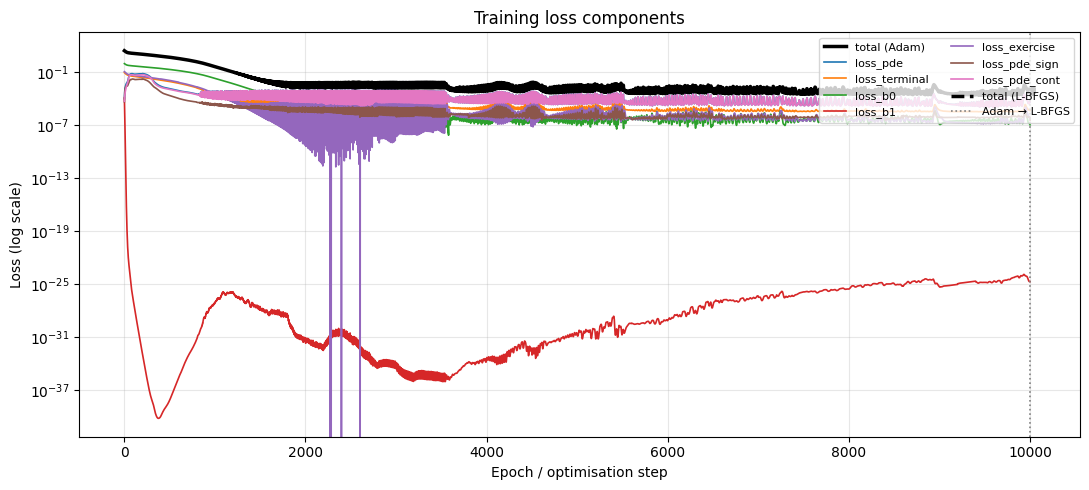

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))

epochs_adam = np.arange(1, len(loss_history) + 1)

# Adam curves
ax.plot(epochs_adam, loss_history, label="total (Adam)", linewidth=2.5, color="black")
for k, v in parts_history.items():
    ax.plot(epochs_adam, v, label=k, linewidth=1.2)

# L-BFGS curves 
if lbfgs_history:
    lbfgs_x = np.arange(len(loss_history), len(loss_history) + len(lbfgs_history))
    ax.plot(lbfgs_x, lbfgs_history, label="total (L-BFGS)",
            linewidth=2.5, linestyle="--", color="black")
    ax.axvline(len(loss_history), color="gray", linestyle=":", linewidth=1.2,
               label="Adam → L-BFGS")

ax.set_yscale("log")
ax.set_xlabel("Epoch / optimisation step")
ax.set_ylabel("Loss (log scale)")
ax.set_title("Training loss components")
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Evaluation

We compare PINN against the Binomial Tree (American put benchmark) on a full (S, t) grid.
We report both **global** and **ATM-band** (S ∈ [80, 120]) errors.

In [8]:
model.eval()

# grid settings 
nS = 60
nT = 30

S_grid_np = np.linspace(S_min + 1.0, S_max, nS)          
t_grid_np = np.linspace(t_min + 1e-2, t_max - 1e-2, nT) 

ATM_LO = K * 0.80   # ATM band relative to K
ATM_HI = K * 1.20

# helper: evaluate PINN on a (S, t) meshgrid 
def eval_pinn_grid(model, S_arr, t_arr):
    """Returns V_pred shaped (len(S_arr), len(t_arr))."""
    SS, TT = np.meshgrid(S_arr, t_arr, indexing="ij")
    dtype  = next(model.parameters()).dtype
    S_t = torch.tensor(SS.reshape(-1, 1), dtype=dtype, device=device)
    t_t = torch.tensor(TT.reshape(-1, 1), dtype=dtype, device=device)
    with torch.no_grad():
        V = model(S_t, t_t).cpu().numpy().reshape(len(S_arr), len(t_arr))
    return V

# binomial tree reference grid 
print("Computing binomial tree reference grid")

V_tree_np = np.zeros((nS, nT))
for j, t_val in enumerate(t_grid_np):
    V_tree_np[:, j] = tree.price_grid(S_grid_np, K, T - t_val, option_type="put")

# PINN predictions 
V_pred = eval_pinn_grid(model, S_grid_np, t_grid_np)

# error metrics 
SS_np, _   = np.meshgrid(S_grid_np, t_grid_np, indexing="ij")
abs_error  = np.abs(V_pred - V_tree_np)
atm_mask   = (S_grid_np >= ATM_LO) & (S_grid_np <= ATM_HI)
payoff_np  = np.maximum(K - SS_np, 0.0)

rel_l2     = np.linalg.norm(V_pred - V_tree_np) / (np.linalg.norm(V_tree_np) + 1e-12)
rel_l2_atm = (np.linalg.norm(V_pred[atm_mask] - V_tree_np[atm_mask]) / (np.linalg.norm(V_tree_np[atm_mask]) + 1e-12))
rmse              = np.sqrt(np.mean(abs_error ** 2))
max_err           = abs_error.max()
max_err_atm       = abs_error[atm_mask].max()
exercise_violation = np.max(np.maximum(payoff_np - V_pred, 0.0))

print(f"\nEvaluation vs binomial tree  (K={K}, r={r}, sigma={sigma}, T={T})")
print(f"  Rel L2 error (global)       : {rel_l2:.6e}")
print(f"  Rel L2 error (ATM {ATM_LO:.0f}-{ATM_HI:.0f})  : {rel_l2_atm:.6e}")
print(f"  RMSE                        : {rmse:.6e}")
print(f"  Max abs error (global)      : {max_err:.6e}")
print(f"  Max abs error (ATM)         : {max_err_atm:.6e}")
print(f"  Max exercise violation      : {exercise_violation:.6e}")

Computing binomial tree reference grid

Evaluation vs binomial tree  (K=100.0, r=0.05, sigma=0.2, T=1.0)
  Rel L2 error (global)       : 1.488099e-03
  Rel L2 error (ATM 80-120)  : 4.577979e-03
  RMSE                        : 6.104280e-02
  Max abs error (global)      : 6.632080e-01
  Max abs error (ATM)         : 1.920343e-01
  Max exercise violation      : 3.200461e-01


## Single Cases

For each $t$ slice we print:
- Summary error metrics (global + ATM Rel L2, RMSE, max errors)
- A **pointwise table**: S | PINN | Tree (American) | BS European | EE Premium | Abs error | Rel error %
- A **two-panel plot**: prices (left) and relative error log-scale (right)


In [9]:
def compare_prices_table(model, S_list, t_value=0.5):
    model.eval()

    S_arr  = np.asarray(S_list, dtype=float)
    tau    = T - t_value

    tree_p = tree.price_grid(S_arr, K, tau, option_type="put")
    bs_p   = bs.price_grid(S_arr,   K, tau, option_type="put")
    pinn_p = eval_pinn_grid(model, S_arr, [t_value])[:, 0]  

    abs_err            = np.abs(pinn_p - tree_p)
    rel_err_pct        = abs_err / np.maximum(tree_p, 0.1) * 100.0
    ee_premium         = tree_p - bs_p
    exercise_violation = np.maximum(np.maximum(K - S_arr, 0.0) - pinn_p, 0.0)

    return pd.DataFrame({
        "S":                   S_arr,
        "t":                   t_value,
        "PINN (American)":     np.round(pinn_p,  4),
        "Tree (American)":     np.round(tree_p,  4),
        "BS (European)":       np.round(bs_p,    4),
        "EE Premium":          np.round(ee_premium,         4),
        "Abs error":           np.round(abs_err,            4),
        "Rel error %":         np.round(rel_err_pct,        3),
        "Exercise violation":  np.round(exercise_violation, 4),
    })


# print tables 
S_values = [40, 60, 70, 80, 90, 100, 110, 120, 140, 160]

for t_val in [0.25, 0.5, 0.75]:
    df = compare_prices_table(model, S_values, t_value=t_val)

    pinn_arr = df["PINN (American)"].values
    tree_arr = df["Tree (American)"].values
    atm_mask = df["S"].between(ATM_LO, ATM_HI)

    rel_l2     = np.linalg.norm(pinn_arr - tree_arr) / (np.linalg.norm(tree_arr) + 1e-12)
    rel_l2_atm = (np.linalg.norm(pinn_arr[atm_mask] - tree_arr[atm_mask])
                  / (np.linalg.norm(tree_arr[atm_mask]) + 1e-12))

    print(f"{'=' * 65}")
    print(f"  t = {t_val}  (tau = {T - t_val:.2f})  |  K={K}, r={r}, sigma={sigma}")
    print(f"{'=' * 65}")
    print(f"  Rel L2 (full slice)          : {rel_l2:.6e}")
    print(f"  Rel L2 (ATM {ATM_LO:.0f}-{ATM_HI:.0f}) : {rel_l2_atm:.6e}")
    print(f"  Max rel error                : {df['Rel error %'].max():.4f}%")
    print(f"  Max exercise violation       : {df['Exercise violation'].max():.4e}")
    print()
    print(df.to_string(index=False))
    print()

  t = 0.25  (tau = 0.75)  |  K=100.0, r=0.05, sigma=0.2
  Rel L2 (full slice)          : 1.051477e-03
  Rel L2 (ATM 80-120) : 2.994442e-03
  Max rel error                : 7.2490%
  Max exercise violation       : 6.2200e-02

    S    t  PINN (American)  Tree (American)  BS (European)  EE Premium  Abs error  Rel error %  Exercise violation
 40.0 0.25        60.035999          60.0000        56.3194      3.6806     0.0360        0.060              0.0000
 60.0 0.25        40.004501          40.0000        36.3319      3.6681     0.0045        0.011              0.0000
 70.0 0.25        29.968800          30.0000        26.5011      3.4989     0.0312        0.104              0.0312
 80.0 0.25        19.937799          20.0000        17.4195      2.5805     0.0622        0.311              0.0622
 90.0 0.25        11.130100          11.1110        10.0747      1.0363     0.0191        0.172              0.0000
100.0 0.25         5.487400           5.4648         5.0917      0.3731     0.0

## Graphs

### Reference price heatmap (Binomial Tree)

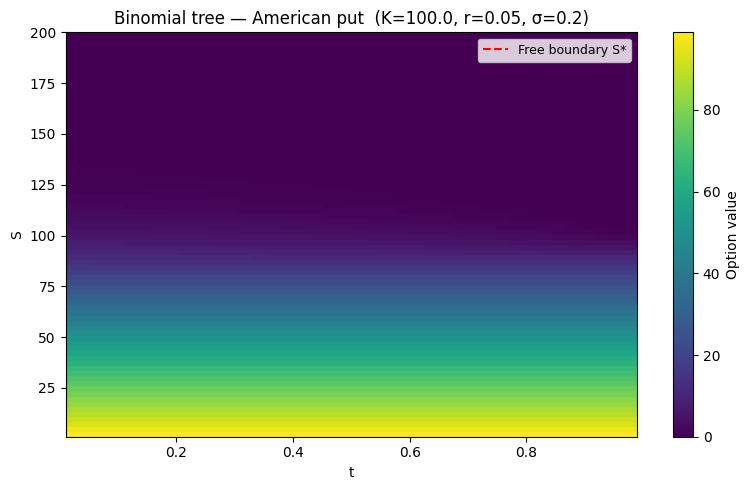

In [10]:
def plot_tree_heatmap(nS=80, nT=40):
    S_vals = np.linspace(S_min + 1.0, S_max, nS)
    t_vals = np.linspace(t_min + 1e-2, t_max - 1e-2, nT)

    V_tree = np.zeros((nS, nT))
    for j, t_val in enumerate(t_vals):
        V_tree[:, j] = tree.price_grid(S_vals, K, T - t_val, option_type="put")

    payoff_1d = np.maximum(K - S_vals, 0.0)
    tol       = 1e-3 * K

    free_S = []
    for j in range(nT):
        exercise_idx = np.where(np.abs(V_tree[:, j] - payoff_1d) < tol)[0]
        free_S.append(S_vals[exercise_idx.max()] if len(exercise_idx) else np.nan)

    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(
        V_tree,
        extent=[t_vals.min(), t_vals.max(), S_vals.min(), S_vals.max()],
        origin="lower", aspect="auto", cmap="viridis",
    )
    ax.plot(t_vals, free_S, color="red", linewidth=1.5,
            linestyle="--", label="Free boundary S*")
    ax.set_xlabel("t")
    ax.set_ylabel("S")
    ax.set_title(f"Binomial tree — American put  (K={K}, r={r}, σ={sigma})")
    ax.legend(fontsize=9)
    fig.colorbar(im, ax=ax, label="Option value")
    fig.tight_layout()
    plt.show()

plot_tree_heatmap()

### PINN vs Binomial Tree vs BS European - slice plots with relative error


 t=0.25  tau=0.750  |  K=100.0, r=0.05, sigma=0.2
 Rel L2 (full slice)              : 9.893541e-04
 Rel L2 (ATM 80-120)        : 2.440180e-03
 RMSE                             : 4.042675e-02
 Max abs error                    : 3.008292e-01
 Max rel error                    : 8.6764%
 Max exercise violation           : 3.008292e-01
 Free boundary S*                 : 200.0000


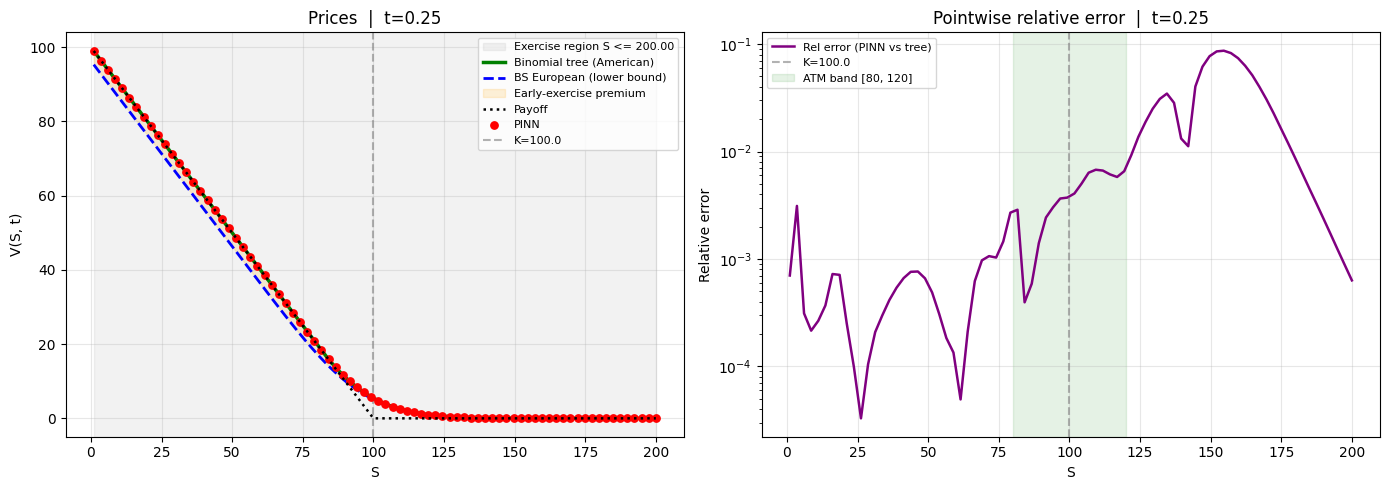


 t=0.5  tau=0.500  |  K=100.0, r=0.05, sigma=0.2
 Rel L2 (full slice)              : 1.402120e-03
 Rel L2 (ATM 80-120)        : 3.063179e-03
 RMSE                             : 5.727496e-02
 Max abs error                    : 3.475517e-01
 Max rel error                    : 5.8071%
 Max exercise violation           : 3.475517e-01
 Free boundary S*                 : 200.0000


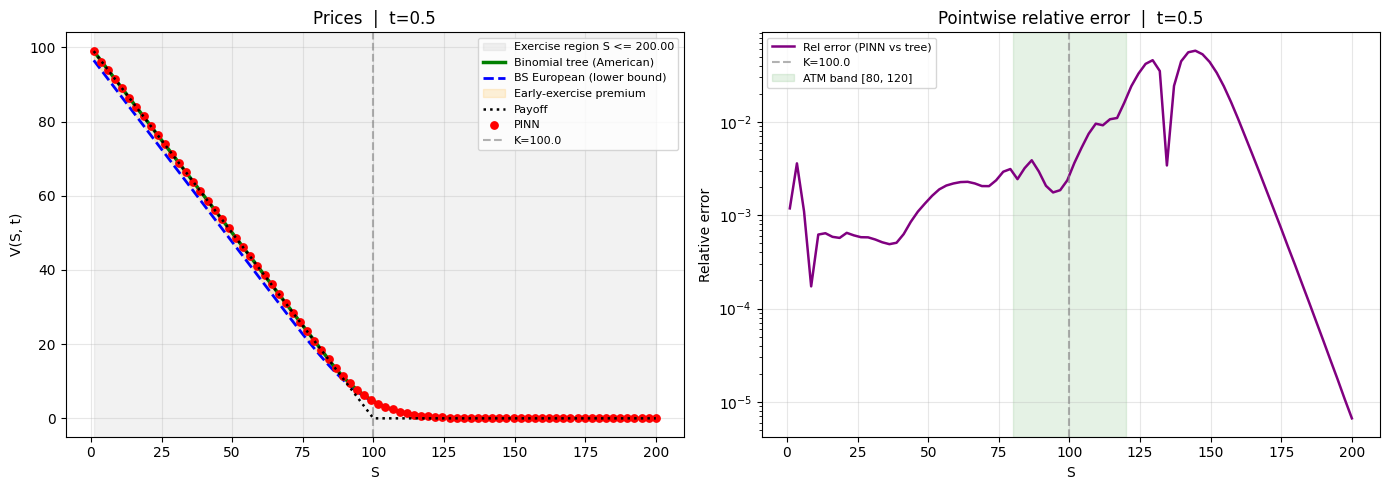


 t=0.75  tau=0.250  |  K=100.0, r=0.05, sigma=0.2
 Rel L2 (full slice)              : 1.278684e-03
 Rel L2 (ATM 80-120)        : 3.023036e-03
 RMSE                             : 5.221644e-02
 Max abs error                    : 3.001731e-01
 Max rel error                    : 4.3258%
 Max exercise violation           : 3.001731e-01
 Free boundary S*                 : 200.0000


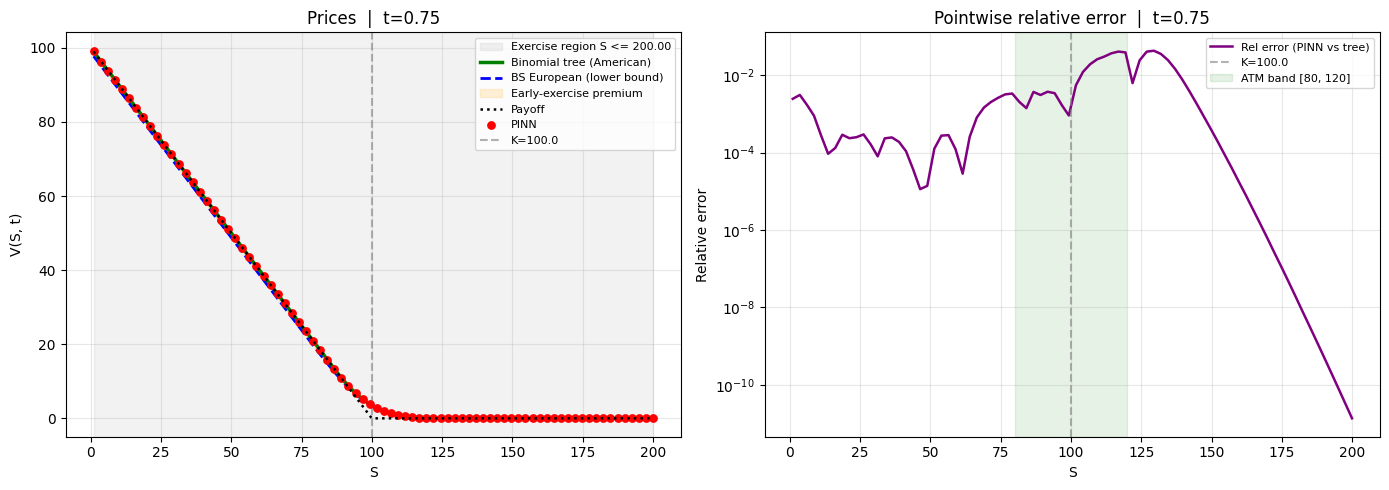

In [11]:
def _find_free_boundary(S_arr, V, payoff, tol=1e-3):
    """
    Returns the highest S where V ≈ payoff (edge of exercise region).
    Returns None if no exercise region is detected.
    """
    exercise_idx = np.where(np.abs(V - payoff) < tol * K)[0]
    return S_arr[exercise_idx.max()] if len(exercise_idx) else None

def plot_single_slice(model, t_value=0.5, nS_line=400, nS_scatter=80):
    """
    Two-panel plot:
      Left  - option prices: PINN vs Tree vs BS European
      Right - pointwise relative error PINN vs Tree (log scale)
    """
    model.eval()

    tau = T - t_value

    S_line = np.linspace(S_min + 1.0, S_max, nS_line)
    S_scat = np.linspace(S_min + 1.0, S_max, nS_scatter)

    tree_line    = tree.price_grid(S_line, K, tau, option_type="put")
    tree_scat    = tree.price_grid(S_scat, K, tau, option_type="put")
    bs_line      = bs.price_grid(S_line,   K, tau, option_type="put")
    payoff_line  = np.maximum(K - S_line, 0.0)
    payoff_scat  = np.maximum(K - S_scat, 0.0)

    pinn_scat = eval_pinn_grid(model, S_scat, [t_value])[:, 0]

    # metrics 
    abs_err  = np.abs(pinn_scat - tree_scat)
    rel_err  = abs_err / np.maximum(tree_scat, 0.1)
    atm_mask = (S_scat >= ATM_LO) & (S_scat <= ATM_HI)

    rel_l2     = np.linalg.norm(pinn_scat - tree_scat) / (np.linalg.norm(tree_scat) + 1e-12)
    rel_l2_atm = (np.linalg.norm(pinn_scat[atm_mask] - tree_scat[atm_mask])
                  / (np.linalg.norm(tree_scat[atm_mask]) + 1e-12))
    rmse               = np.sqrt(np.mean((pinn_scat - tree_scat) ** 2))
    exercise_violation = np.max(np.maximum(payoff_scat - pinn_scat, 0.0))

    S_star = _find_free_boundary(S_line, tree_line, payoff_line)

    # print summary 
    print(f"\n{'=' * 55}")
    print(f" t={t_value}  tau={tau:.3f}  |  K={K}, r={r}, sigma={sigma}")
    print(f"{'=' * 55}")
    print(f" Rel L2 (full slice)              : {rel_l2:.6e}")
    print(f" Rel L2 (ATM {ATM_LO:.0f}-{ATM_HI:.0f})        : {rel_l2_atm:.6e}")
    print(f" RMSE                             : {rmse:.6e}")
    print(f" Max abs error                    : {abs_err.max():.6e}")
    print(f" Max rel error                    : {rel_err.max():.4%}")
    print(f" Max exercise violation           : {exercise_violation:.6e}")
    print(f" Free boundary S*                 : {f'{S_star:.4f}' if S_star else 'not detected'}")

    # plot 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # left: prices
    ax = axes[0]
    if S_star is not None:
        ax.axvspan(S_line.min(), S_star, alpha=0.10, color="gray", label=f"Exercise region S <= {S_star:.2f}", zorder=0)
    ax.plot(S_line, tree_line, color="green", lw=2.5, label="Binomial tree (American)", zorder=3)
    ax.plot(S_line, bs_line, color="blue", lw=2.0, ls="--", label="BS European (lower bound)", zorder=2)
    ax.fill_between(S_line, bs_line, tree_line, color="orange", alpha=0.15, label="Early-exercise premium", zorder=1)
    ax.plot(S_line, payoff_line, color="black", lw=1.8, ls=":", label="Payoff",  zorder=5)
    ax.scatter(S_scat, pinn_scat, color="red", s=28, label="PINN", zorder=4)
    ax.axvline(K, color="gray", ls="--", alpha=0.6, label=f"K={K}")
    ax.set_xlabel("S")
    ax.set_ylabel("V(S, t)")
    ax.set_title(f"Prices  |  t={t_value}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # right: relative error
    ax = axes[1]
    ax.semilogy(S_scat, rel_err, color="purple", lw=1.8, label="Rel error (PINN vs tree)")
    ax.axvline(K, color="gray", ls="--", alpha=0.6, label=f"K={K}")
    ax.axvspan(ATM_LO, ATM_HI, alpha=0.10, color="green",
               label=f"ATM band [{ATM_LO:.0f}, {ATM_HI:.0f}]")
    ax.set_xlabel("S")
    ax.set_ylabel("Relative error")
    ax.set_title(f"Pointwise relative error  |  t={t_value}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()


for t_val in [0.25, 0.5, 0.75]:
    plot_single_slice(model, t_value=t_val)

### Error Heatmap - |PINN - Binomial Tree|

Max abs error          : 6.632080e-01
Mean abs error         : 3.266317e-02
Max relative error     : 1.901479e-01
Max exercise violation : 3.200461e-01


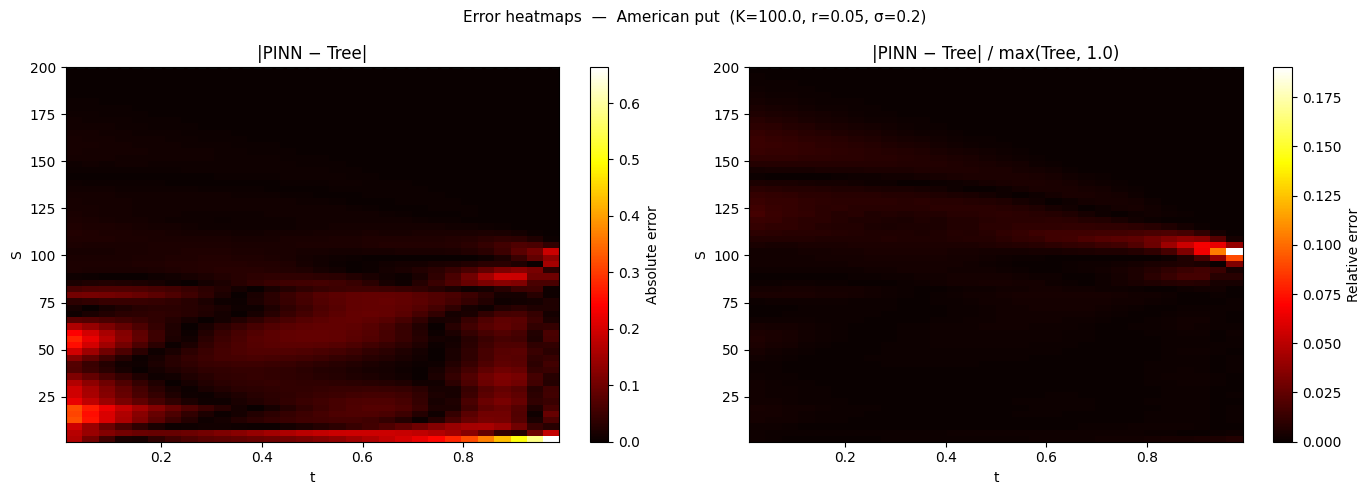

In [15]:
def plot_error_heatmap(model, nS=60, nT=30):
    model.eval()

    S_vals = np.linspace(S_min + 1.0, S_max, nS)
    t_vals = np.linspace(t_min + 1e-2, t_max - 1e-2, nT)

    if nS == V_tree_np.shape[0] and nT == V_tree_np.shape[1]:
        V_tree = V_tree_np
        V_pinn = V_pred
    else:
        V_tree = np.zeros((nS, nT))
        for j, t_val in enumerate(t_vals):
            V_tree[:, j] = tree.price_grid(S_vals, K, T - t_val, option_type="put")
        V_pinn = eval_pinn_grid(model, S_vals, t_vals)

    SS                 = np.meshgrid(S_vals, t_vals, indexing="ij")[0]
    abs_err            = np.abs(V_pinn - V_tree)
    rel_err            = abs_err / np.maximum(V_tree, 0.01 * K)
    payoff             = np.maximum(K - SS, 0.0)
    exercise_violation = np.maximum(payoff - V_pinn, 0.0)

    print(f"Max abs error          : {abs_err.max():.6e}")
    print(f"Mean abs error         : {abs_err.mean():.6e}")
    print(f"Max relative error     : {rel_err.max():.6e}")
    print(f"Max exercise violation : {exercise_violation.max():.6e}")

    # free boundary per time slice
    payoff_1d = np.maximum(K - S_vals, 0.0)
    tol       = 1e-3 * K
    free_S    = []
    for j in range(nT):
        s_star = _find_free_boundary(S_vals, V_tree[:, j], payoff_1d, tol=tol)
        free_S.append(s_star if s_star is not None else np.nan)

    extent = [t_vals.min(), t_vals.max(), S_vals.min(), S_vals.max()]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, title, cbar_label in zip(
        axes,
        [abs_err, rel_err],
        ["|PINN − Tree|", f"|PINN − Tree| / max(Tree, {0.01*K:.1f})"],
        ["Absolute error", "Relative error"],
    ):
        im = ax.imshow(data, extent=extent, origin="lower", aspect="auto", cmap="hot")
        ax.plot(t_vals, free_S, color="cyan", lw=1.5, ls="--", label="Free boundary S*")
        ax.set_xlabel("t")
        ax.set_ylabel("S")
        ax.set_title(title)
        fig.colorbar(im, ax=ax, label=cbar_label)

    fig.suptitle(f"Error heatmaps  —  American put  (K={K}, r={r}, σ={sigma})", fontsize=11)
    fig.tight_layout()
    plt.show()

plot_error_heatmap(model)

### PINN vs Tree vs BS across time slices

Because the PINN learned the **full 2D surface**, we can query it at any $(S, t)$.
Each panel shows one time slice with all three methods and the early-exercise premium (shaded).
The left boundary of the orange region marks the **free boundary**, the critical $S^*$ below which early exercise is optimal.


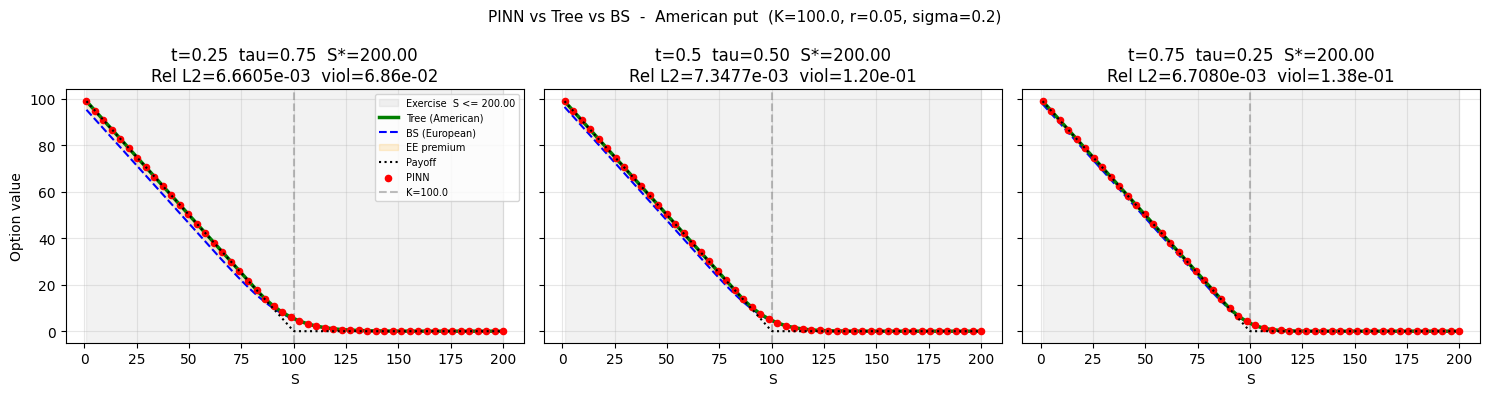

In [13]:
def plot_pinn_vs_tree_multiple_t(model, t_values=None, nS_line=300, nS_scatter=50):
    if t_values is None:
        t_values = [0.25, 0.5, 0.75]

    model.eval()

    S_line = np.linspace(S_min + 1.0, S_max, nS_line)
    S_scat = np.linspace(S_min + 1.0, S_max, nS_scatter)

    scat_idx = np.searchsorted(S_line, S_scat).clip(0, nS_line - 1)

    fig, axes = plt.subplots(1, len(t_values),
                             figsize=(5 * len(t_values), 4), sharey=True)
    if len(t_values) == 1:
        axes = [axes]

    for i, (ax, t_val) in enumerate(zip(axes, t_values)):
        tau = T - t_val

        tree_line   = tree.price_grid(S_line, K, tau, option_type="put")
        bs_line     = bs.price_grid(S_line,   K, tau, option_type="put")
        payoff_line = np.maximum(K - S_line, 0.0)

        pinn_scat   = eval_pinn_grid(model, S_scat, [t_val])[:, 0]
        tree_scat   = tree_line[scat_idx]   # reuse tree_line, no extra tree call
        payoff_scat = np.maximum(K - S_scat, 0.0)

        rel_l2             = (np.linalg.norm(pinn_scat - tree_scat) / (np.linalg.norm(tree_scat) + 1e-12))
        exercise_violation = np.max(np.maximum(payoff_scat - pinn_scat, 0.0))

        S_star = _find_free_boundary(S_line, tree_line, payoff_line)

        if S_star is not None:
            ax.axvspan(S_line.min(), S_star, alpha=0.10, color="gray",
                       label=f"Exercise  S <= {S_star:.2f}", zorder=0)

        ax.plot(S_line, tree_line, color="green", lw=2.5, label="Tree (American)", zorder=3)
        ax.plot(S_line, bs_line, color="blue",  lw=1.5, ls="--", label="BS (European)",  zorder=2)
        ax.fill_between(S_line, bs_line, tree_line, color="orange", alpha=0.15, label="EE premium", zorder=1)
        ax.plot(S_line, payoff_line, color="black", lw=1.5, ls=":", label="Payoff", zorder=5)
        ax.scatter(S_scat, pinn_scat, color="red", s=20, label="PINN", zorder=4)
        ax.axvline(K, color="gray", ls="--", alpha=0.5, label=f"K={K}")

        boundary_str = f"  S*={S_star:.2f}" if S_star is not None else ""
        ax.set_title(
            f"t={t_val}  tau={tau:.2f}{boundary_str}\n"
            f"Rel L2={rel_l2:.4e}  viol={exercise_violation:.2e}"
        )
        ax.set_xlabel("S")
        ax.grid(True, alpha=0.3)

        # legend only on first panel
        if i == 0:
            ax.legend(fontsize=7)

    axes[0].set_ylabel("Option value")
    fig.suptitle(
        f"PINN vs Tree vs BS  -  American put  (K={K}, r={r}, sigma={sigma})",
        fontsize=11
    )
    fig.tight_layout()
    plt.show()


plot_pinn_vs_tree_multiple_t(model, t_values=[0.25, 0.5, 0.75])